In [ ]:
# Import libraries and display data
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

df = pd.read_csv(
    'https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv')

print("Shape")
print(df.shape)
print(df.head())
print(df.info())

print("Missing Values")
print(df.isna().sum())

print("Duplicate Rows")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates After Drop")
print(df.duplicated().sum())
print(df.describe())

Shape
(1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
Missing Values
age         0
sex         0
bmi         0
children    0
smok

In [2]:
for column in ["sex", "smoker", "region"]:
    print(f"\n {column}:")
    print(df[column].value_counts())


 sex:
male      675
female    662
Name: sex, dtype: int64

 smoker:
no     1063
yes     274
Name: smoker, dtype: int64

 region:
southeast    364
southwest    325
northeast    324
northwest    324
Name: region, dtype: int64


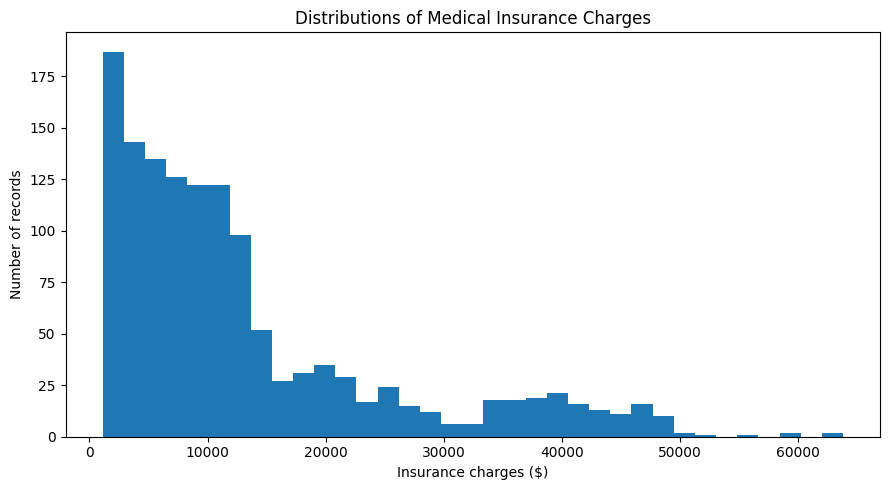

In [ ]:
# Distribution histogram
plt.figure(figsize=(9, 5))
plt.hist(df["charges"], bins=35)
plt.xlabel("Insurance charges ($)")
plt.ylabel("Number of records")
plt.title("Distributions of Medical Insurance Charges")
plt.tight_layout()
plt.show()

### Analysis
I removed the 1 duplicate row in the dataset and based on the graph above most individual medical costs are below \$15,000.

In [4]:
# Split data
x = df.drop(columns="charges")
y = df["charges"]

x_development, x_test, y_development, y_test = train_test_split(
    x,
    y,
    test_size=.2,
    random_state=54321
)

x_train, x_valid, y_train, y_valid = train_test_split(
    x_development,
    y_development,
    test_size=.2,
    random_state=54321
)

print(f"Training records: {len(x_train):,}")
print(f"Validation records: {len(x_valid):,}")
print(f"Test records: {len(x_test):,}")

Training records: 855
Validation records: 214
Test records: 268


### Data-Splitting Decisions

I separated the predictor variables from charges and divided the dataset into 855 training records, 214 validation records, and 268 test records. The training set updates the model’s weights, the validation set monitors performance during training, and the test set is reserved for the final evaluation.

Using a fixed random_state makes the split reproducible. Keeping the test set separate until the end helps provide a fair estimate of performance on unseen data.

In [ ]:
# Transform data
numeric_features = ["age", "bmi", "children"]
categorical_features = ["sex", "smoker", "region"]

one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse=False
)

feature_preprocessor = ColumnTransformer(
    transformers=[

        ("numeric", StandardScaler(), numeric_features),
        ("categorical", one_hot_encoder, categorical_features)
    ],
    remainder="drop"
)

x_train_processed = feature_preprocessor.fit_transform(
    x_train).astype("float32")

x_valid_processed = feature_preprocessor.transform(x_valid).astype("float32")

x_test_processed = feature_preprocessor.transform(x_test).astype("float32")


print("Processed training shape:", x_train_processed.shape)

# Encoded columns names
fitted_encoder = feature_preprocessor.named_transformers_["categorical"]

encoded_names = fitted_encoder.get_feature_names(categorical_features)

feature_names = numeric_features + list(encoded_names)

print(feature_names)
target_scaler = StandardScaler()

y_train_scaled = target_scaler.fit_transform(
    y_train.to_numpy().reshape(-1, 1)).astype("float32")

y_valid_scaled = target_scaler.transform(
    y_valid.to_numpy().reshape(-1, 1)).astype("float32")

y_test_scaled = target_scaler.transform(
    y_test.to_numpy().reshape(-1, 1)).astype("float32")

Processed training shape: (855, 11)
['age', 'bmi', 'children', 'sex_female', 'sex_male', 'smoker_no', 'smoker_yes', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


### Data-Preprocessing Decisions

I standardized age, bmi, and children with StandardScaler and converted sex, smoker, and region into numerical columns with one-hot encoding. This produced 11 processed input features.

The preprocessing tools were fitted only on the training data to prevent data leakage. I also standardized the target because insurance charges have a wide range, and I converted the processed arrays to float32 for TensorFlow and Keras.

In [ ]:
# Build model
model = Sequential()

model.add(Dense(64, activation="relu",
                kernel_initializer=HeNormal(),
                kernel_regularizer=l2(.001),
                input_shape=(11,)))
model.add(BatchNormalization())
model.add(Dropout(.3))

model.add(Dense(32, activation="relu",
                kernel_initializer=HeNormal(),
                kernel_regularizer=l2(.001)
                ))
model.add(BatchNormalization())
model.add(Dropout(.3))

model.add(Dense(16, activation="relu",
                kernel_initializer=HeNormal(),
                kernel_regularizer=l2(.001)))
model.add(BatchNormalization())
model.add(Dropout(.3))

model.add(Dense(1, activation="linear"))

model.compile(
    optimizer=Adam(learning_rate=.001),
    loss="mse",
    metrics=["mae"]
)

model.summary()

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=False,
        mode="min",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=.5,
        patience=5,
        min_lr=.000001,
        verbose=1,
        mode="min"
    )
]

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_1 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 32)                0

2026-07-28 21:43:30.440411: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


### Model-Architecture Decisions

I used hidden layers containing 64, 32, and 16 neurons with ReLU activation. Batch normalization, 30% dropout, and L2 regularization of 0.001 were included to improve training stability and reduce overfitting.

The output layer contains one linear neuron because this is a regression problem. The model uses Adam with a learning rate of 0.001, mean squared error loss, and mean absolute error as an additional metric.

In [ ]:
# Train model
history = model.fit(
    x_train_processed,
    y_train_scaled,
    validation_data=(
        x_valid_processed,
        y_valid_scaled
    ),
    epochs=300,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/300
 1/27 [>.............................] - ETA: 18s - loss: 5.9405 - mae: 1.7435
Epoch 00001: val_loss improved from inf to 1.10064, saving model to best_model.keras
27/27 [==============================] - 1s 10ms/step - loss: 3.7337 - mae: 1.4175 - val_loss: 1.1006 - val_mae: 0.7945 - lr: 0.0010
Epoch 2/300
 1/27 [>.............................] - ETA: 0s - loss: 3.5994 - mae: 1.4283
Epoch 00002: val_loss improved from 1.10064 to 0.81451, saving model to best_model.keras
27/27 [==============================] - 0s 5ms/step - loss: 2.5057 - mae: 1.1588 - val_loss: 0.8145 - val_mae: 0.6062 - lr: 0.0010
Epoch 3/300
 1/27 [>.............................] - ETA: 0s - loss: 2.0723 - mae: 1.0741
Epoch 00003: val_loss improved from 0.81451 to 0.72462, saving model to best_model.keras
27/27 [==============================] - 0s 5ms/step - loss: 2.1182 - mae: 1.0458 - val_loss: 0.7246 - val_mae: 0.5200 - lr: 0.0010
Epoch 4/300
 1/27 [>.............................] - ETA: 0s - loss: 

In [8]:
best_epoch_index = np.argmin(history.history["val_loss"])
best_epoch = best_epoch_index + 1

best_train_loss = history.history["loss"][best_epoch_index]
best_train_mae = history.history["mae"][best_epoch_index]
best_validation_loss = history.history["val_loss"][best_epoch_index]
best_validation_mae = history.history["val_mae"][best_epoch_index]

epochs_completed = len(history.history["loss"])

print(f"Epochs completed: {epochs_completed}")
print(f"Best epoch: {best_epoch}")
print(f"Training loss at best epoch: {best_train_loss:.4f}")
print(f"Training MAE at best epoch: {best_train_mae:.4f}")
print(f"Validation loss at best epoch: {best_validation_loss:.4f}")
print(f"Validation MAE at best epoch: {best_validation_mae:.4f}")

Epochs completed: 293
Best epoch: 278
Training loss at best epoch: 0.2881
Training MAE at best epoch: 0.3425
Validation loss at best epoch: 0.2058
Validation MAE at best epoch: 0.2198


### Model-Training Decisions

The model was trained for up to 300 epochs with a batch size of 32. Early stopping, model checkpointing, and learning-rate reduction were used to preserve the best model and prevent unnecessary training.

Training stopped after 293 epochs, while the lowest validation loss occurred at epoch 278. Because restore_best_weights=True, early stopping restored the model’s weights from epoch 278. In addition, save_best_only=True ensured that model checkpointing saved only the version with the lowest validation loss.

In [ ]:
# Model predict
test_predictions_scaled = model.predict(
    x_test_processed,
    verbose=0
)

### Test-Prediction Decision

The trained model generated one standardized insurance-charge prediction for each observation in the test set. The test set was used only after training and model selection were complete.

The predict() method performs forward passes through the network without updating the model’s weights. The predictions were initially in standardized units because the target had been scaled before training.

In [ ]:
# Model evaluation
test_loss_scaled, test_mae_scaled = model.evaluate(
    x_test_processed,
    y_test_scaled,
    verbose=0
)

### Model-Evaluation Decision

The evaluate() method calculated the test loss and test mean absolute error using the final trained model. Evaluation does not update the weights or perform additional training.

Because the standardized test target was used, the initial loss and MAE results were measured in standardized units rather than dollars.

In [11]:
# Transform to normal scaling
test_predictions = target_scaler.inverse_transform(
    test_predictions_scaled
).ravel()

### Converting Predictions Back to Dollars

I used inverse_transform() to convert the model’s standardized predictions back into actual dollar amounts. This made the predictions directly comparable with the original insurance charges.

After inverse transformation, ravel() converted the predictions into a one-dimensional array that matched the shape of y_test.

In [12]:
# Test metrics
test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

test_mse = mean_squared_error(
    y_test,
    test_predictions
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    test_predictions
)

print(f"Test loss in scaled units: {test_loss_scaled:.4f}")
print(f"Test MAE in scaled units: {test_mae_scaled:.4f}")
print(f"Test MAE: ${test_mae:,.2f}")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Test R2: {test_r2:.4f}")

Test loss in scaled units: 0.1458
Test MAE in scaled units: 0.1722
Test MAE: $2,168.14
Test RMSE: $3,798.14
Test R2: 0.8873


### Model Evaluation

The final model achieved a standardized test loss of 0.1458 and a standardized test MAE of 0.1722. In dollar terms, the test MAE was 2,168.14 dollars, the RMSE was 3,798.14 dollars, and the R² score was 0.8873.

The model explained approximately 88.73% of the variation in unseen insurance charges and was about 2,168 dollars away from the actual value on average. The results suggest that the model is well-balanced rather than clearly underfitting or overfitting.

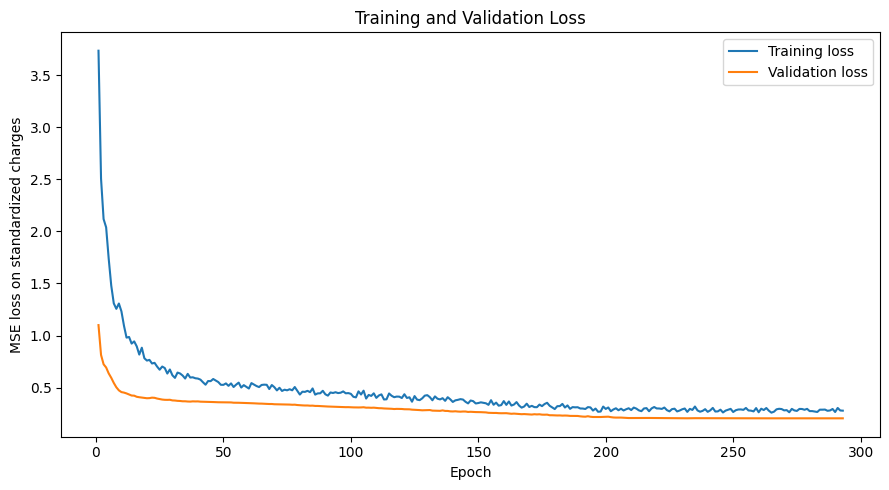

In [13]:
# Training history over epochs
epochs_run = range(
    1,
    len(history.history["loss"]) + 1
)

plt.figure(figsize=(9, 5))

plt.plot(
    epochs_run,
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    epochs_run,
    history.history["val_loss"],
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("MSE loss on standardized charges")
plt.title("Training and Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

### Training-History Analysis

Training and validation loss both decreased substantially during the early epochs and then improved more gradually. Validation loss did not begin consistently increasing while training loss continued decreasing.

The curves suggest that the model learned useful patterns without developing a clear overfitting problem. The lowest validation loss occurred at epoch 278, and early stopping restored the weights from that epoch.

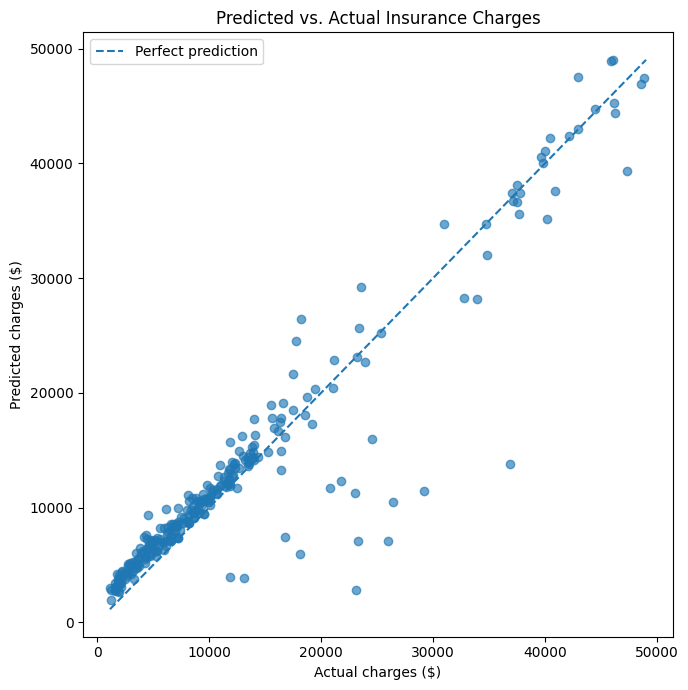

In [ ]:
# Prediction vs actual
minimum_value = min(
    y_test.min(),
    test_predictions.min()
)

maximum_value = max(
    y_test.max(),
    test_predictions.max()
)

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.65
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("Actual charges ($)")
plt.ylabel("Predicted charges ($)")
plt.title("Predicted vs. Actual Insurance Charges")
plt.legend()
plt.tight_layout()
plt.show()

### Predictions Versus Actual Charges

Most predictions follow the upward direction of the diagonal perfect-prediction line. Many low and moderate insurance-charge predictions are located reasonably close to the line.

Some medium- and high-cost observations are farther from the diagonal, showing that the model still makes larger errors on certain expensive cases. Overall, the plot is consistent with the R² score of 0.8873.

In [15]:
prediction_results = pd.DataFrame(
    {
        "actual_charges": y_test.to_numpy(),
        "predicted_charges": test_predictions
    }
)

prediction_results["absolute_error"] = (
    prediction_results["actual_charges"]
    - prediction_results["predicted_charges"]
).abs()

display(
    prediction_results.sample(
        n=10,
        random_state=54321
    )
)

model.summary()

,actual_charges,predicted_charges,absolute_error
182,9095.06825,9520.240234,425.171984
95,14382.70905,14443.237305,60.528255
204,13887.96850,14428.272461,540.303961
37,6313.75900,8278.638672,1964.879672
88,2203.47185,4463.502930,2260.031080
22,3597.59600,4700.913086,1103.317086
231,15230.32405,14856.727539,373.596511
156,48549.17835,46919.152344,1630.026006
263,1137.01100,2953.645508,1816.634508
68,6571.54400,7497.950195,926.406195


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                768       
                                                                 
 batch_normalization (BatchN  (None, 64)               256       
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_1 (Batc  (None, 32)               128       
 hNormalization)                                                 
                                                                 
 dropout_1 (Dropout)         (None, 32)                0

### Model Architecture

The displayed test examples had absolute errors ranging from approximately 60.53 to 2,260.03 dollars. The predictions generally made sense because the model distinguished between low-cost, moderate-cost, and high-cost observations, although it overpredicted some of the lowest charges.

The model contains 3,841 total parameters, including 3,617 trainable parameters and 224 non-trainable parameters. Its final architecture uses 11 inputs, hidden layers of 64, 32, and 16 neurons, and one linear output neuron.

## Final Project Summary
### Process

I loaded the medical-insurance dataset and reviewed its shape, data types, missing values, duplicate rows, descriptive statistics, categorical variables, and insurance-charge distribution. The dataset originally contained 1,338 records with no missing values. I removed one duplicate, leaving 1,337 records. The target variable was strongly right-skewed, with most charges below approximately 15,000 dollars and a smaller number of much higher charges.

I divided the data into 855 training records, 214 validation records, and 268 test records. I standardized age, bmi, and children, and one-hot encoded sex, smoker, and region, producing 11 input features. All preprocessing tools were fitted only on the training data to prevent data leakage. I also standardized the target variable and converted predictions back into dollars before calculating the final metrics.

### Model Architecture and Experimentation

The final neural network used hidden layers containing 64, 32, and 16 neurons with ReLU activation and He-normal initialization. Batch normalization was added after each hidden layer to improve training stability. A dropout rate of 30% and L2 regularization of 0.001 were used to reduce overfitting. The output layer contained one linear neuron because the model predicts one continuous insurance charge.

The model used the Adam optimizer with a learning rate of 0.001, mean squared error loss, a batch size of 32, and a maximum of 300 epochs. During development, I adjusted hyperparameters including the number and size of the hidden layers, dropout rate, regularization strength, learning rate, batch size, and callback patience. Early stopping, model checkpointing, and learning-rate reduction were used to preserve the best model and prevent unnecessary training. The best validation result occurred at epoch 278, and training ended after 293 epochs.

### Results

The final standardized test loss was 0.1458, and the standardized test mean absolute error was 0.1722. After converting the predictions back into dollars, the model achieved a mean absolute error of 2,168.14 dollars, a root mean squared error of 3,798.14 dollars, and an R² score of 0.8873. This means the predictions were approximately 2,168 dollars away from the actual insurance charge on average, and the model explained approximately 88.73% of the variation in the test data.

At the best validation epoch, the training loss was approximately 0.2881 and the training MAE was approximately 0.3425. The validation loss was approximately 0.2058 and the validation MAE was approximately 0.2198. The test results were slightly better than the logged training and validation results. This is partly because dropout is active during training but disabled during validation and testing.

### Qualitative Evaluation

The displayed test examples had absolute errors ranging from approximately 60.53 to 2,260.03 dollars. This means the closest displayed prediction was only about 61 dollars away from the actual charge, while the least accurate displayed prediction was about 2,260 dollars away.

Overall, the predictions were reasonably close to the actual values, although accuracy varied between observations. The predictions-versus-actual graph also showed that most points followed the diagonal perfect-prediction line, with some larger errors among individual cases.

### Model Diagnosis and Visualizations

The training and validation loss curves both decreased and did not develop a large gap. Validation loss did not begin consistently increasing while training loss continued falling, so the model does not show the usual signs of overfitting. The strong test R² and relatively low test error also suggest that the model is not underfitting. Overall, the model appears well-balanced and appropriately regularized.

The final architecture contained 3,841 total parameters, including 3,617 trainable parameters and 224 non-trainable batch-normalization parameters. The training-history graph showed steady learning, while the predictions-versus-actual graph showed that most predictions were reasonably close to the diagonal line, with larger errors concentrated among certain unusual cases.

### Best Configuration

The best configuration used 11 processed inputs, hidden layers of 64, 32, and 16 neurons, ReLU activation, He-normal initialization, batch normalization, 30% dropout, and L2 regularization of 0.001. It used Adam with a learning rate of 0.001, a batch size of 32, early-stopping patience of 15 epochs, and learning-rate-reduction patience of five epochs.

### Future Improvements

With more time, I would test other model settings, compare the neural network with other regression models, and examine the largest prediction errors. I would also consider transforming the charges variable to help the model handle the highly skewed distribution.